# LangGraph Subgraphs

This notebook demonstrates two practical ways to use a subgraph inside a parent graph. The first example shares one state schema. The second example uses a separate subgraph state and runs one subgraph per topic with `Send`.


## Architecture Overview

| Example | Integration style | State relationship | Main purpose |
|---|---|---|---|
| Order Processing | Add the compiled subgraph directly as a parent node | Parent and subgraph share `OrderState` | Group related order-processing steps |
| Parallel Research | Invoke the subgraph inside a worker | Parent, worker, and subgraph use different state schemas | Reuse one subgraph for dynamically created tasks |

```text
Example 1
START → validate_request → [check_inventory → calculate_price] → final_response → END

Example 2
                              ┌→ worker(topic 1) → research subgraph ─┐
START → prepare_topics → Send ├→ worker(topic 2) → research subgraph ─┼→ combine_results → END
                              └→ worker(topic 3) → research subgraph ─┘
```


In [3]:
from typing import Annotated, TypedDict
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

In [36]:
def show_graph(compiled_graph, *, xray=False):
    """Print the generated graph as Mermaid text."""

    print(
        compiled_graph.get_graph(
            xray=xray
        ).draw_mermaid()
    )


## 1. Shared-State Order Subgraph

### What it does

The parent graph validates an order. A nested subgraph checks inventory and calculates the price. The parent then creates the final response.

### Why it is a subgraph

`order_subgraph` is compiled separately and added to the parent as the `order_processing` node. Because both graphs use `OrderState`, state values pass between them automatically.

### Simple real-world example

An online store receives an order, checks whether enough items are available, calculates the total, and then confirms or rejects the order.


In [3]:
class OrderState(TypedDict):
    product: str
    quantity: int
    inventory_status: str
    total_price: float
    final_response: str

In [4]:
PRODUCT_CATALOG = {
    "Keyboard": {"stock": 5, "unit_price": 500.0},
    "Mouse": {"stock": 10, "unit_price": 250.0},
}

### 1.1 Subgraph nodes

`check_inventory` updates availability. `calculate_price` uses the selected product and requested quantity.


In [5]:
def check_inventory(state: OrderState):
    print("Checking inventory...")

    product = PRODUCT_CATALOG[state["product"]]
    is_available = product["stock"] >= state["quantity"]

    return {
        "inventory_status": (
            "Available" if is_available else "Unavailable"
        )
    }

In [6]:
def calculate_price(state: OrderState):
    print("Calculating price...")

    if state["inventory_status"] != "Available":
        return {"total_price": 0.0}

    unit_price = PRODUCT_CATALOG[state["product"]]["unit_price"]

    return {
        "total_price": state["quantity"] * unit_price
    }


### 1.2 Build the order subgraph


In [7]:
order_subgraph_builder = StateGraph(OrderState)

In [8]:
order_subgraph_builder.add_node(
    "check_inventory",
    check_inventory,
)

order_subgraph_builder.add_node(
    "calculate_price",
    calculate_price,
)

In [9]:
order_subgraph_builder.add_edge(
    START,
    "check_inventory",
)

order_subgraph_builder.add_edge(
    "check_inventory",
    "calculate_price",
)

order_subgraph_builder.add_edge(
    "calculate_price",
    END,
)

In [10]:
order_subgraph = order_subgraph_builder.compile()

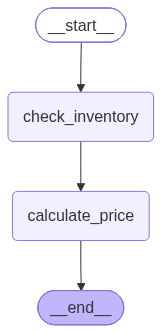

In [11]:
order_subgraph

### 1.3 Parent graph nodes


In [12]:
def validate_request(state: OrderState):
    print("Validating request...")

    if state["product"] not in PRODUCT_CATALOG:
        raise ValueError(f"Unknown product: {state['product']}")

    if state["quantity"] <= 0:
        raise ValueError("Quantity must be greater than zero.")

    return {}

In [13]:
def create_final_response(state: OrderState):
    if state["inventory_status"] == "Available":
        response = (
            f"{state['quantity']} {state['product']} ordered. "
            f"Total Price: ₹{state['total_price']:,.2f}"
        )
    else:
        response = (
            f"Order not placed. {state['quantity']} "
            f"{state['product']} are not available."
        )

    return {
        "final_response": response
    }


### 1.4 Build the parent graph


In [19]:
order_builder = StateGraph(OrderState)

In [20]:
order_builder.add_node(
    "validate_request",
    validate_request,
)

In [21]:
# The complete compiled subgraph becomes one parent node.
order_builder.add_node(
    "order_processing",
    order_subgraph,
)

In [22]:
order_builder.add_node(
    "final_response",
    create_final_response,
)

In [23]:
order_builder.add_edge(
    START,
    "validate_request",
)

order_builder.add_edge(
    "validate_request",
    "order_processing",
)

order_builder.add_edge(
    "order_processing",
    "final_response",
)

order_builder.add_edge(
    "final_response",
    END,
)

In [24]:
order_graph = order_builder.compile()

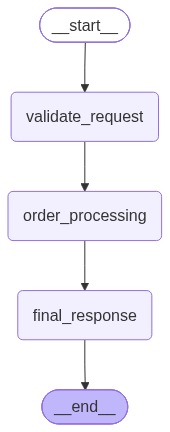

In [25]:
order_graph

### 1.5 Generated graph structure

`xray=True` expands the nested subgraph inside the parent graph. This cell does not make a model call.


In [26]:
show_graph(
    order_graph,
    xray=True,
)


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	validate_request(validate_request)
	final_response(final_response)
	__end__([<p>__end__</p>]):::last
	__start__ --> validate_request;
	order_processing\3acalculate_price --> final_response;
	validate_request --> order_processing\3acheck_inventory;
	final_response --> __end__;
	subgraph order_processing
	order_processing\3acheck_inventory(check_inventory)
	order_processing\3acalculate_price(calculate_price)
	order_processing\3acheck_inventory --> order_processing\3acalculate_price;
	end
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### 1.6 Test the order workflow

**Model calls:** 0

**Expected behavior:** The request is validated, inventory is checked, the price is calculated, and the final confirmation shows ₹1,000.00.


In [27]:
def run_order_workflow():
    result = order_graph.invoke(
        {
            "product": "Keyboard",
            "quantity": 2,
        }
    )

    print(result["final_response"])

    return result


In [29]:
order_result = run_order_workflow()

Validating request...
Checking inventory...
Calculating price...
2 Keyboard ordered. Total Price: ₹1,000.00


In [30]:
def run_order_workflow():
    result = order_graph.invoke(
        {
            "product": "Monitor",
            "quantity": 5,
        }
    )

    print(result["final_response"])

    return result

In [31]:
order_result = run_order_workflow()


Validating request...


ValueError: Unknown product: Monitor

In [32]:
def run_order_workflow():
    result = order_graph.invoke(
        {
            "product": "Keyboard",
            "quantity": 50,
        }
    )

    print(result["final_response"])

    return result

In [33]:
order_result = run_order_workflow()

Validating request...
Checking inventory...
Calculating price...
Order not placed. 50 Keyboard are not available.


In [34]:
order_result

{'product': 'Keyboard',
 'quantity': 50,
 'inventory_status': 'Unavailable',
 'total_price': 0.0,
 'final_response': 'Order not placed. 50 Keyboard are not available.'}

In [35]:
def run_order_workflow():
    result = order_graph.invoke(
        {
            "product": "Keyboard",
            "quantity": 2,
        }
    )

    print(result["final_response"])


In [36]:
order_result = run_order_workflow()

Validating request...
Checking inventory...
Calculating price...
2 Keyboard ordered. Total Price: ₹1,000.00


**Common mistake:** A direct subgraph node works cleanly here because the parent and subgraph share the same state keys.

**Student exercise:** Change the quantity to `6` and confirm that the order is rejected because only five keyboards are available.


## 2. Parallel Research Subgraph with `Send`

### What it does

The parent graph creates one worker per topic. Each worker invokes the same research subgraph, and the parent combines all summaries.

### Why this integration is different

The parent uses `ParentState`, each worker receives `ResearchWorkerInput`, and the subgraph uses `ResearchState`. The worker acts as an adapter between these different schemas.

### Simple real-world example

A research coordinator assigns different topics to researchers. Every researcher follows the same research-and-summary process, and an instructor combines the completed summaries.


In [1]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv()

model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0,
)

### 2.1 Parent, worker, and subgraph states


In [9]:
class ParentState(TypedDict):
    topics: list[str]
    research_results: Annotated[
        list[str],
        operator.add,
    ]
    final_answer: str

In [10]:
class ResearchWorkerInput(TypedDict):
    topic: str

In [11]:
class ResearchState(TypedDict):
    topic: str
    research: str
    summary: str


### 2.2 Research subgraph nodes


In [12]:
def research_topic(state: ResearchState):
    topic = state["topic"]
    print(f"[SUBGRAPH] Researching: {topic}")

    response = model.invoke(
        f"""
Explain this Generative AI topic: {topic}

Include:
1. A definition
2. Important concepts
3. One practical use case

Keep the explanation concise.
"""
    )

    return {
        "research": response.content
    }

In [13]:
def summarize_topic(state: ResearchState):
    print(f"[SUBGRAPH] Summarizing: {state['topic']}")

    response = model.invoke(
        f"""
Create a concise summary of this research.

Topic: {state['topic']}

Research:
{state['research']}
"""
    )

    return {
        "summary": response.content
    }

### 2.3 Build the research subgraph


In [14]:
from typing import Annotated, TypedDict
import operator

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

In [15]:
class ResearchState(TypedDict):
    topic: str
    research: str
    summary: str

In [16]:
research_builder = StateGraph(ResearchState)

In [17]:
research_builder.add_node(
    "research_topic",
    research_topic,
)

research_builder.add_node(
    "summarize_topic",
    summarize_topic,
)

In [18]:
research_builder.add_edge(
    START,
    "research_topic",
)

research_builder.add_edge(
    "research_topic",
    "summarize_topic",
)

research_builder.add_edge(
    "summarize_topic",
    END,
)

In [19]:
research_subgraph = research_builder.compile()

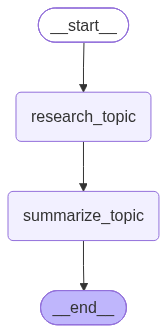

In [20]:
research_subgraph

### 2.4 Parent graph nodes

`Send` creates one worker input per topic. The reducer on `research_results` safely combines worker outputs.


In [21]:
def prepare_topics(state: ParentState):
    print("Topics received:")

    for topic in state["topics"]:
        print(f"- {topic}")

    return {}

In [22]:
def distribute_topics(state: ParentState):
    return [
        Send("research_worker", {"topic": topic})
        for topic in state["topics"]
    ]


Send("research_worker", {"topic": "RAG"})

Send("research_worker", {"topic": "AI Agents"})

Send("research_worker", {"topic": "Memory"})

In [ ]:
def research_worker(state: ResearchWorkerInput):
    topic = state["topic"]
    print(f"[WORKER] Starting: {topic}")

    subgraph_result = research_subgraph.invoke(
        {
            "topic": topic,
            "research": "",
            "summary": "",
        }
    )

    return {
        "research_results": [
            f"## {topic}\n\n{subgraph_result['summary']}"
        ]
    }

In [23]:
def combine_results(state: ParentState):
    combined_research = "\n\n".join(
        state["research_results"]
    )

    response = model.invoke(
        f"""
Combine these research summaries into one clear explanation.
Keep each topic under its own heading.

{combined_research}
"""
    )

    return {
        "final_answer": response.content
    }


### 2.5 Build the parent graph


#### How the conditional edge works

The following conditional edge has three simple parts:

1. **source = prepare_topics:** LangGraph runs the prepare_topics node first. The topics remain available in the parent state.
2. **path = distribute_topics:** After prepare_topics finishes, LangGraph calls distribute_topics. This is a routing function, not a graph node. It returns one Send instruction for every topic.
3. **path_map = [research_worker]:** This tells LangGraph that research_worker is a possible destination. It helps graph validation and allows the static diagram to display the dynamic route. This list does not create the workers; the Send instructions create them.

For example, three topics produce three tasks:

    Send("research_worker", {"topic": "RAG"})
    Send("research_worker", {"topic": "AI Agents"})
    Send("research_worker", {"topic": "Memory"})

LangGraph can run these tasks in parallel. Each task executes the same research_worker node with a different topic. The research_worker then invokes the research subgraph.

    prepare_topics
          |
          v
    distribute_topics        routing function, not a node
          |
          v
    multiple Send tasks
          |
          v
    research_worker          parent graph node
          |
          v
    research_subgraph        invoked inside the worker
          |
          v
    combine_results

It is called a conditional edge because the next tasks are decided dynamically from the current state. An if/else statement is not required.


In [29]:
class ParentState(TypedDict):
    topics: list[str]
    research_results: Annotated[
        list[str],
        operator.add,
    ]
    final_answer: str

In [30]:
research_parent_builder = StateGraph(ParentState)

In [31]:
research_parent_builder.add_node(
    "prepare_topics",
    prepare_topics,
)

research_parent_builder.add_node(
    "research_worker",
    research_worker,
)

research_parent_builder.add_node(
    "combine_results",
    combine_results,
)

In [32]:
research_parent_builder.add_edge(
    START,
    "prepare_topics",
)

research_parent_builder.add_conditional_edges(
    source="prepare_topics",
    path=distribute_topics,
    path_map=["research_worker"],
)

research_parent_builder.add_edge(
    "research_worker",
    "combine_results",
)

research_parent_builder.add_edge(
    "combine_results",
    END,
)

In [33]:
research_graph = research_parent_builder.compile()

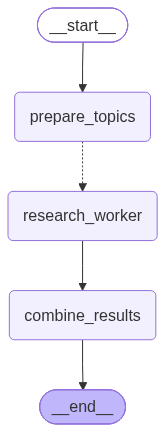

In [34]:
research_graph

### 2.6 Generated graph structures

The subgraph is invoked inside `research_worker`, so the parent diagram does not expand it automatically. Displaying both graphs makes the relationship clear.

If an older saved output shows disconnected nodes, restart the kernel and run Sections 2.1 through 2.6 again. The destination list in `add_conditional_edges` gives the static diagram enough information to draw the dynamic `Send` route.


In [37]:
print("RESEARCH SUBGRAPH")
show_graph(research_subgraph)

RESEARCH SUBGRAPH
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	research_topic(research_topic)
	summarize_topic(summarize_topic)
	__end__([<p>__end__</p>]):::last
	__start__ --> research_topic;
	research_topic --> summarize_topic;
	summarize_topic --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [38]:
print("PARENT GRAPH")
show_graph(research_graph)

PARENT GRAPH
---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	prepare_topics(prepare_topics)
	research_worker(research_worker)
	combine_results(combine_results)
	__end__([<p>__end__</p>]):::last
	__start__ --> prepare_topics;
	prepare_topics -.-> research_worker;
	research_worker --> combine_results;
	combine_results --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



### 2.7 Test the parallel research workflow

**Model calls:** 7 for the three-topic test: two calls per topic plus one final combination call.

**Expected behavior:** Three workers are created, each worker runs the two-node research subgraph, three results are collected, and one combined answer is printed. Worker log order may vary because the tasks can run in parallel.


In [39]:
def run_parallel_research_workflow():
    result = research_graph.invoke(
        {
            "topics": [
                "Retrieval-Augmented Generation",
                "AI Agents",
                "Memory Management",
            ],
            "research_results": [],
        }
    )

    print("\nFINAL ANSWER\n")
    print(result["final_answer"])

    return result


In [40]:
research_result = run_parallel_research_workflow()

Topics received:
- Retrieval-Augmented Generation
- AI Agents
- Memory Management
[WORKER] Starting: Retrieval-Augmented Generation
[SUBGRAPH] Researching: Retrieval-Augmented Generation
[WORKER] Starting: AI Agents
[SUBGRAPH] Researching: AI Agents
[WORKER] Starting: Memory Management
[SUBGRAPH] Researching: Memory Management
[SUBGRAPH] Summarizing: AI Agents
[SUBGRAPH] Summarizing: Retrieval-Augmented Generation
[SUBGRAPH] Summarizing: Memory Management

FINAL ANSWER

## Retrieval-Augmented Generation

Retrieval-Augmented Generation (RAG) is a generative AI technique that improves large language models by incorporating external information retrieval. It combines a retriever component, which fetches relevant documents from a knowledge base, with a generator that produces informed and contextually rich responses. Some RAG systems are trained end-to-end to optimize both retrieval and generation simultaneously. This approach is particularly useful in applications like customer support, w

In [41]:
def run_parallel_research_workflow():
    result = research_graph.invoke(
        {
            "topics": [
                "american dollar",
                "Indian Rupees",
                "kuwait Dinar",
            ],
            "research_results": [],
        }
    )

    print("\nFINAL ANSWER\n")
    print(result["final_answer"])

    return result

In [42]:
research_result = run_parallel_research_workflow()

Topics received:
- american dollar
- Indian Rupees
- kuwait Dinar
[WORKER] Starting: american dollar
[SUBGRAPH] Researching: american dollar
[WORKER] Starting: Indian Rupees
[SUBGRAPH] Researching: Indian Rupees
[WORKER] Starting: kuwait Dinar
[SUBGRAPH] Researching: kuwait Dinar
[SUBGRAPH] Summarizing: american dollar
[SUBGRAPH] Summarizing: Indian Rupees
[SUBGRAPH] Summarizing: kuwait Dinar

FINAL ANSWER

## American Dollar

The American dollar (USD) is the official currency of the United States and serves as the world’s primary reserve currency, extensively used in global trade and finance. As a fiat currency, its value is upheld by government authority and public trust. The Federal Reserve controls its supply and monetary policy, with its exchange rate fluctuating based on economic conditions, thereby influencing international trade. Many countries hold the USD in their reserves, highlighting its global financial significance. In generative AI applications, the USD is used to creat

## 3. Send API: Practical Scenarios

Send is a dynamic routing instruction. It tells LangGraph which registered node should receive a state payload. A single Send object always has one destination and one payload.

Use the term **parallel tasks** or **parallel worker executions**. They are not necessarily separate operating-system threads; the runtime decides how concurrency is implemented.

### Core rule

| Pattern | Meaning |
|---|---|
| One Send object | One destination and one payload |
| A list of Send objects with the same destination | Run the same worker once for each payload |
| A list of Send objects with different destinations | Run different registered nodes or subgraphs |
| One Send to a wrapper node | The wrapper controls any additional work internally |


### 3.1 Scenario 1: Send multiple topics to the same worker

This is the pattern used by the research workflow above. The routing function returns one Send object per topic. Every task targets the same research_worker node, and every worker invokes the same research subgraph with a different topic.

Real-world example: A research assistant receives three topics and creates one independent research task for each topic.


In [43]:
topic_tasks = distribute_topics(
    {
        "topics": ["RAG", "Agents", "Memory"],
        "research_results": [],
        "final_answer": "",
    }
)

for task in topic_tasks:
    print(task)

Send(node='research_worker', arg={'topic': 'RAG'})
Send(node='research_worker', arg={'topic': 'Agents'})
Send(node='research_worker', arg={'topic': 'Memory'})


### 3.2 Scenario 2: Send work to two different subgraphs

A single routing function can return multiple Send objects with different destinations. In this example, one subgraph converts text to uppercase while another counts the words. Both subgraphs are registered as nodes in the parent graph.

Real-world example: When a document arrives, one branch extracts information while another branch checks document quality. The parent combines both results after the parallel work finishes.

The subgraphs define explicit input and output schemas. Their output contains only results, which prevents both parallel branches from writing to the parent's text key at the same time.


In [44]:
class BranchInput(TypedDict):
    text: str


class BranchOutput(TypedDict):
    results: list[str]


class BranchState(TypedDict):
    text: str
    results: list[str]


class MultiGraphState(TypedDict):
    text: str
    results: Annotated[list[str], operator.add]
    final_answer: str

In [45]:
def make_uppercase(state: BranchState):
    return {
        "results": [f"Uppercase: {state['text'].upper()}"]
    }

In [46]:
uppercase_builder = StateGraph(BranchState,input_schema=BranchInput,output_schema=BranchOutput)

In [47]:
uppercase_builder.add_node("make_uppercase", make_uppercase)

In [48]:
uppercase_builder.add_edge(START, "make_uppercase")

In [49]:
uppercase_builder.add_edge("make_uppercase", END)

In [50]:
uppercase_graph = uppercase_builder.compile()

In [51]:
def count_words(state: BranchState):
    word_count = len(state["text"].split())
    return {
        "results": [f"Word count: {word_count}"]
    }

In [52]:
word_count_builder = StateGraph(
    BranchState,
    input_schema=BranchInput,
    output_schema=BranchOutput,
)
word_count_builder.add_node("count_words", count_words)
word_count_builder.add_edge(START, "count_words")
word_count_builder.add_edge("count_words", END)
word_count_graph = word_count_builder.compile()

In [ ]:
def send_to_different_subgraphs(state: MultiGraphState):
    return [
        Send(
            "uppercase_graph",
            {"text": state["text"]},
        ),
        Send(
            "word_count_graph",
            {"text": state["text"]},
        ),
    ]


In [ ]:
# Send("uppercase_graph",{"text": state["text"]},word_count_graph",{"text": state["text"]})

In [54]:


def combine_branch_results(state: MultiGraphState):
    return {
        "final_answer": " | ".join(state["results"])
    }

In [55]:
multi_graph_builder = StateGraph(MultiGraphState)

In [56]:
multi_graph_builder.add_node(
    "uppercase_graph",
    uppercase_graph,
)

In [57]:
multi_graph_builder.add_node(
    "word_count_graph",
    word_count_graph,
)

In [58]:
multi_graph_builder.add_node(
    "combine",
    combine_branch_results,
)

In [59]:
multi_graph_builder.add_conditional_edges(
    START,
    send_to_different_subgraphs,
    ["uppercase_graph", "word_count_graph"],
)

In [60]:
multi_graph_builder.add_edge("uppercase_graph", "combine")

In [61]:
multi_graph_builder.add_edge("word_count_graph", "combine")

In [62]:


multi_graph_builder.add_edge("combine", END)

In [63]:
multi_subgraph_parent = multi_graph_builder.compile()

#### Test: two different subgraphs

**Model calls:** 0

**Expected behavior:** The parent sends the same text to two different subgraphs. Their outputs are merged by the results reducer, and combine runs after both branches finish.


In [64]:
show_graph(multi_subgraph_parent)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	uppercase_graph(uppercase_graph)
	word_count_graph(word_count_graph)
	combine(combine)
	__end__([<p>__end__</p>]):::last
	__start__ -.-> uppercase_graph;
	__start__ -.-> word_count_graph;
	uppercase_graph --> combine;
	word_count_graph --> combine;
	combine --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



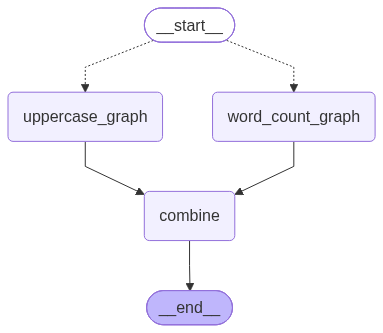

In [65]:
from IPython.display import Image, display

display(
    Image(
        multi_subgraph_parent.get_graph().draw_mermaid_png()
    )
)

In [66]:
multi_subgraph_result = multi_subgraph_parent.invoke(
    {
        "text": "LangGraph sends parallel tasks",
        "results": [],
        "final_answer": "",
    }
)

print(multi_subgraph_result["final_answer"])

Uppercase: LANGGRAPH SENDS PARALLEL TASKS | Word count: 4


### 3.3 Scenario 3: One Send object and a wrapper node

One Send object cannot contain two destination names. A destination such as a list of graph names is invalid.

If one Send must start a unit of work that uses two graphs, send the task to one wrapper node. The wrapper can invoke both graphs internally. In the example below, the calls are sequential because invoke is called one after the other. Use multiple Send objects when LangGraph should schedule the branches in parallel.

Real-world example: A fixed document-processing step always runs formatting first and word counting second. A wrapper can keep those operations together as one unit.


In [ ]:
class WrapperState(TypedDict):
    text: str
    results: list[str]


In [69]:
def run_two_graphs_in_wrapper(state: WrapperState):
    uppercase_result = uppercase_graph.invoke(
        {"text": state["text"]}
    )
    count_result = word_count_graph.invoke(
        {"text": state["text"]}
    )

    return {
        "results": (
            uppercase_result["results"]
            + count_result["results"]
        )
    }

In [70]:
def send_to_wrapper(state: WrapperState):
    return Send(
        "two_graph_wrapper",
        {"text": state["text"]},
    )

In [71]:
wrapper_builder = StateGraph(WrapperState)

In [72]:
wrapper_builder.add_node(
    "two_graph_wrapper",
    run_two_graphs_in_wrapper,
)

In [73]:
wrapper_builder.add_conditional_edges(
    START,
    send_to_wrapper,
    ["two_graph_wrapper"],
)

In [74]:
wrapper_builder.add_edge("two_graph_wrapper", END)

In [75]:
wrapper_graph = wrapper_builder.compile()

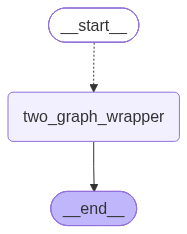

In [76]:
from IPython.display import Image, display

display(
    Image(
        wrapper_graph.get_graph().draw_mermaid_png()
    )
)

#### Test: one Send to one wrapper

**Model calls:** 0

**Expected behavior:** Send targets only two_graph_wrapper. The wrapper then invokes the uppercase and word-count subgraphs sequentially.


In [77]:
wrapper_result = wrapper_graph.invoke(
    {"text": "One Send has one destination"}
)

print(wrapper_result["results"])

['Uppercase: ONE SEND HAS ONE DESTINATION', 'Word count: 5']


### 3.4 Important Send notes

1. The first Send argument must be the name of a node registered in the parent graph.
2. A Send payload should contain the state required by that destination.
3. Parallel branches that update the same parent key need a reducer. Here, operator.add combines all result lists.
4. The destination list passed to add_conditional_edges helps static graph visualization show dynamic Send routes.
5. A graph diagram shows one worker or subgraph node even when runtime creates many parallel executions of it.
6. Use multiple Send objects for LangGraph-managed parallel fan-out. Use a wrapper when several operations intentionally belong to one task.


**Common mistakes:** Removing the reducer from `research_results`, forgetting the `Send` destination list, or expecting the manually invoked subgraph to appear inside the parent diagram.

**Student exercise:** Add a fourth topic and confirm that LangGraph creates a fourth worker automatically.
